#### We will create a function that will return roots of quadratic equation

d = b^2-4ac

3 conditions:

1. d>0: 2 real roots (-b +- d^0.5)/2a
2. d= 0: 2 roots with same value: -b/2a
3. d<0 : No real root

In [4]:
import numpy as np
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Annotated, Literal

In [8]:
class QuadState(TypedDict):
    a: float
    b: float
    c: float 
    discriminant: float
    equation: str
    result: str

In [16]:
def show_equation(state: QuadState):
    
    equation= f"({state['a']})x^2+({state['b']})x+({state['c']})"
    return {'equation': equation}

In [17]:
def calculate_discriminant(state: QuadState):
    
    d= (state['b']**2)-4*(state['a']*state['c'])
    return {'discriminant': d}

In [27]:
def real_roots(state: QuadState):
    
    root1 = (-state['b'] + ((state['b']**2) - 4 * state['a'] * state['c'])**0.5) / (2 * state['a'])
    root2 = (-state['b'] - ((state['b']**2) - 4 * state['a'] * state['c'])**0.5) / (2 * state['a'])

    
    result= f"2 Real roots of the equation are: {root1} and {root2}"
    return {'result': result}


def equal_roots(state: QuadState):
    
    root= (-state['b']) / (2*state['a'])
    
    result= f"Both equal roots of the equation are: {root}"
    return {'result': result}


def non_real_roots(state: QuadState):
    
    result= f"No real root of the equation"
    return {'result': result}

In [31]:
# Returns the name of the functions available as options
def check_condition(state: QuadState) -> Literal['real_roots', 'equal_roots', 'non_real_roots']:
    
    if state['discriminant'] > 0:
        return 'real_roots'
    
    elif state['discriminant'] == 0:
        return 'equal_roots'
    
    else:
        return 'non_real_roots'

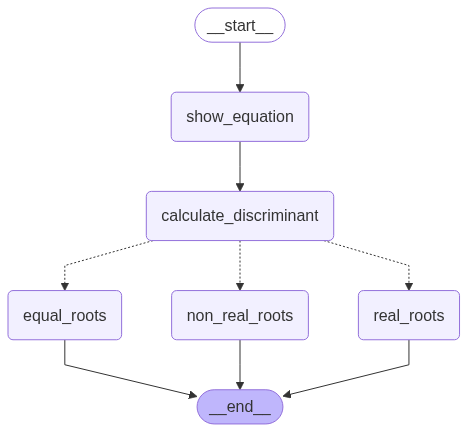

In [29]:
graph= StateGraph(QuadState)
graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)

graph.add_node('real_roots', real_roots)
graph.add_node('equal_roots', equal_roots)
graph.add_node('non_real_roots', non_real_roots)


# add egdes
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')

# conditional edge (takes name of function as edge, which is not added as a node)
graph.add_conditional_edges('calculate_discriminant', check_condition)

graph.add_edge('real_roots', END)
graph.add_edge('equal_roots', END)
graph.add_edge('non_real_roots', END)

workflow= graph.compile()
workflow

In [30]:
initial_state= {'a': 3,
                'b': -6,
                'c': 3}

final_state= workflow.invoke(initial_state)
final_state

{'a': 3,
 'b': -6,
 'c': 3,
 'discriminant': 0,
 'equation': '(3)x^2+(-6)x+(3)',
 'result': 'Both equal roots of the equation are: 1.0'}